# E5c - Anchor-mask control (reproducer)

Top-to-bottom reproducer for the E5c experiment, an extension of E5b
with two additional irrelevant-image arms:

- **anchor**: original digit image at distance stratum S1..S5 (E5b condition).
- **masked**: pixel-masked variant of the same digit image, S1..S5.
- **neutral**: digit-free distractor image, single across-distances bucket.

12 conditions total: target_only + 5 anchor + 5 masked + 1 neutral.

Headline metric: **paired conditional adoption** (case 4 `base=a=pred` excluded
from the denominator). Stratified by (dataset, stratum, base_correct, condition_type).

The two questions this answers:
1. **Digit-pixel causality** — does masking the digit kill the anchoring effect?
   Comparison: anchor vs masked at the same stratum.
2. **Generic 2-image distraction** — is masked > neutral, i.e. does merely having a
   second image (with structure but no digits) move the model? Comparison:
   masked vs neutral.

All heavy lifting in `scripts/analyze_e5c_distance.py` - this notebook just invokes it and displays.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'scripts'))
from analyze_e5c_distance import run
out = run()
summary = out['summary']
print(f"loaded {out['n_records']} records, wrote {out['out_csv']}")

loaded 24000 records, wrote docs/insights/_data/E5c_per_cell.csv


## Per-cell summary

Rows: (dataset, stratum, base, condition_type). For anchor and masked, `stratum`
iterates S1..S5; for neutral the row collapses to a single `stratum=all` bucket.

`adopt_cond = case2 / (case1+case2+case3)` — fraction of eligible records where the
model moved to the anchor digit (paired definition, case 4 excluded). For neutral
rows there is no anchor digit, so `adopt_cond` is structurally 0 and serves as the
baseline floor.

In [2]:
import pandas as pd
pd.set_option('display.float_format', '{:0.4f}'.format)
summary

,dataset,stratum,stratum_range,stratum_midpoint,base,condition_type,n_total,case1,case2,case3,case4,n_eligible,n_adopted,adopt_cond,adopt_cond_ci_lo,adopt_cond_ci_hi,adopt_uncond
0,VQAv2,S1,"[0,1]",0.5000,correct,anchor,601,341,36,24,200,401,36,0.0898,0.0648,0.1197,0.0599
1,VQAv2,S2,"[2,5]",3.5000,correct,anchor,601,580,21,0,0,601,21,0.0349,0.0200,0.0499,0.0349
2,VQAv2,S3,"[6,30]",18.0000,correct,anchor,601,588,13,0,0,601,13,0.0216,0.0116,0.0333,0.0216
3,VQAv2,S4,"[31,300]",165.0000,correct,anchor,601,590,11,0,0,601,11,0.0183,0.0083,0.0300,0.0183
4,VQAv2,S5,"[301,inf)",650.0000,correct,anchor,601,591,10,0,0,601,10,0.0166,0.0067,0.0266,0.0166
5,VQAv2,S1,"[0,1]",0.5000,correct,masked,601,357,20,23,201,400,20,0.0500,0.0300,0.0725,0.0333
6,VQAv2,S2,"[2,5]",3.5000,correct,masked,601,597,4,0,0,601,4,0.0067,0.0017,0.0133,0.0067
7,VQAv2,S3,"[6,30]",18.0000,correct,masked,601,601,0,0,0,601,0,0.0000,0.0000,0.0000,0.0000
8,VQAv2,S4,"[31,300]",165.0000,correct,masked,601,601,0,0,0,601,0,0.0000,0.0000,0.0000,0.0000
9,VQAv2,S5,"[301,inf)",650.0000,correct,masked,601,601,0,0,0,601,0,0.0000,0.0000,0.0000,0.0000


## Anchor vs masked-anchor (wrong-base only)

If digit-pixel content is what causes anchoring, masked should sit substantially
below anchor at every stratum (especially S1 where the anchor is closest to GT).

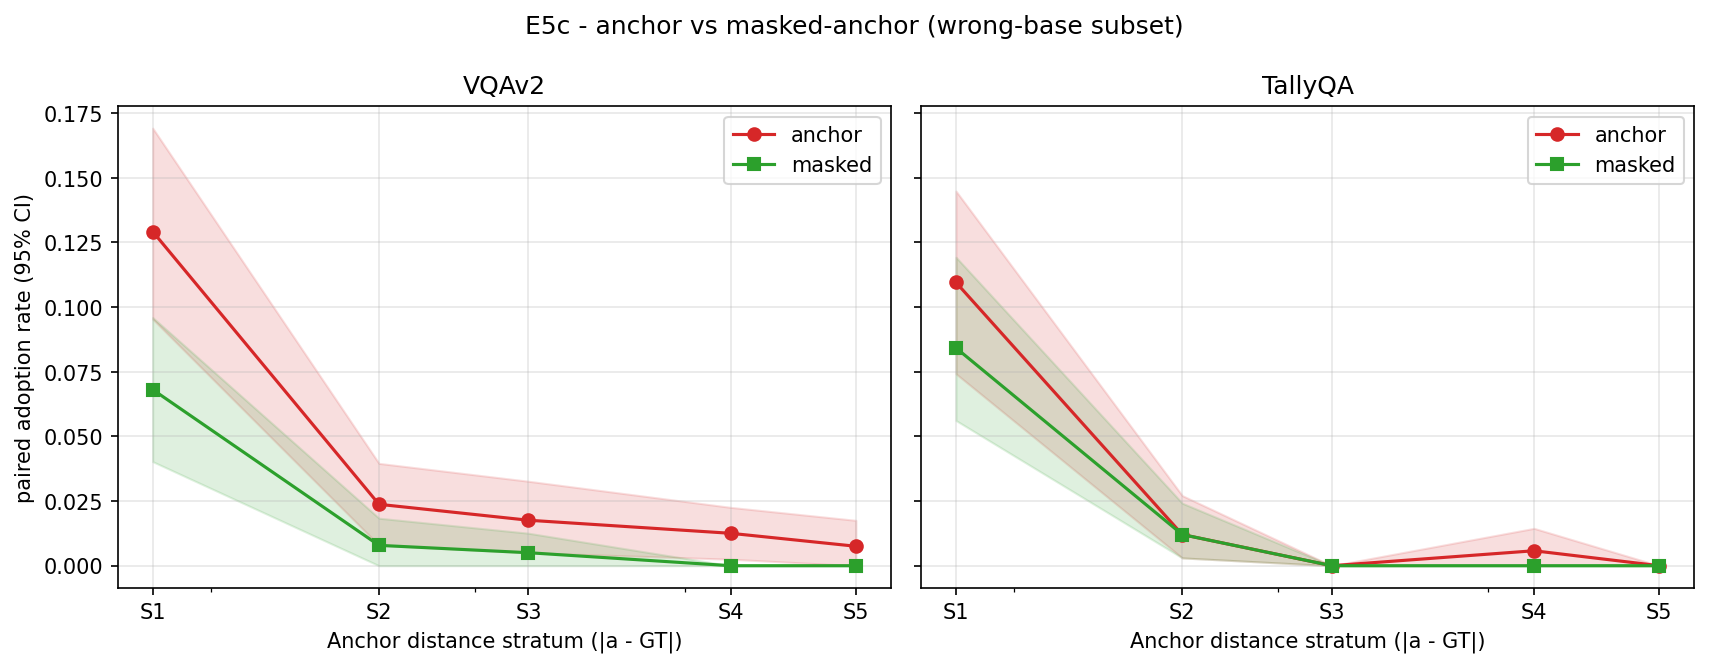

In [3]:
from IPython.display import Image, display
display(Image(filename=str(ROOT / 'docs' / 'figures' / 'E5c_anchor_vs_masked.png')))

## Three-way comparison (wrong-base only)

Anchor and masked across S1..S5, with neutral drawn as a horizontal reference
(stratum-collapsed). The vertical separation between the three lines decomposes the
anchoring effect into (a) digit-pixel content (anchor − masked) and (b) generic
2-image distraction (masked − neutral).

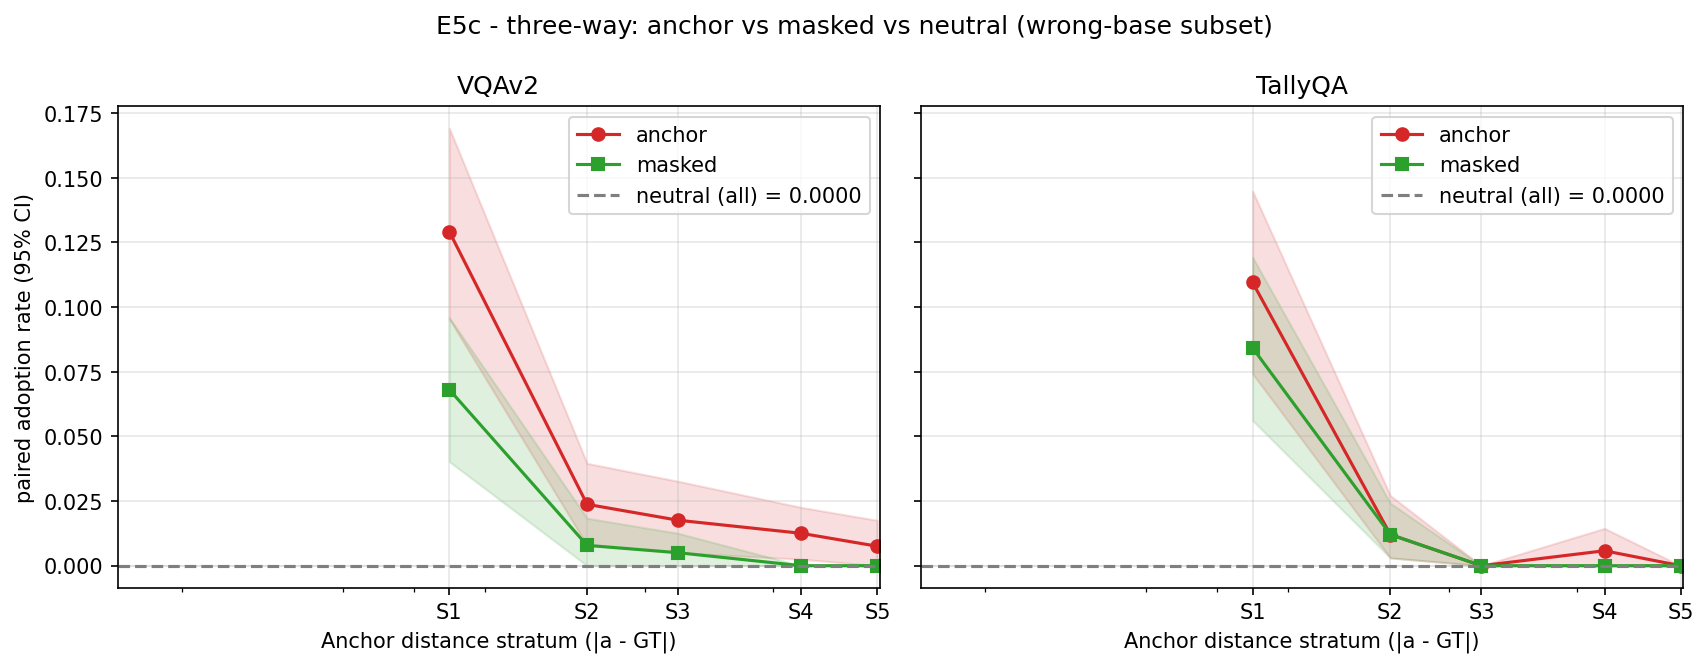

In [4]:
display(Image(filename=str(ROOT / 'docs' / 'figures' / 'E5c_three_way_comparison.png')))

## Anchor adoption: correct-base vs wrong-base (sanity)

E5b found that anchor adoption is gated on the model being uncertain (wrong-base).
This panel re-checks the gating in the E5c re-run.

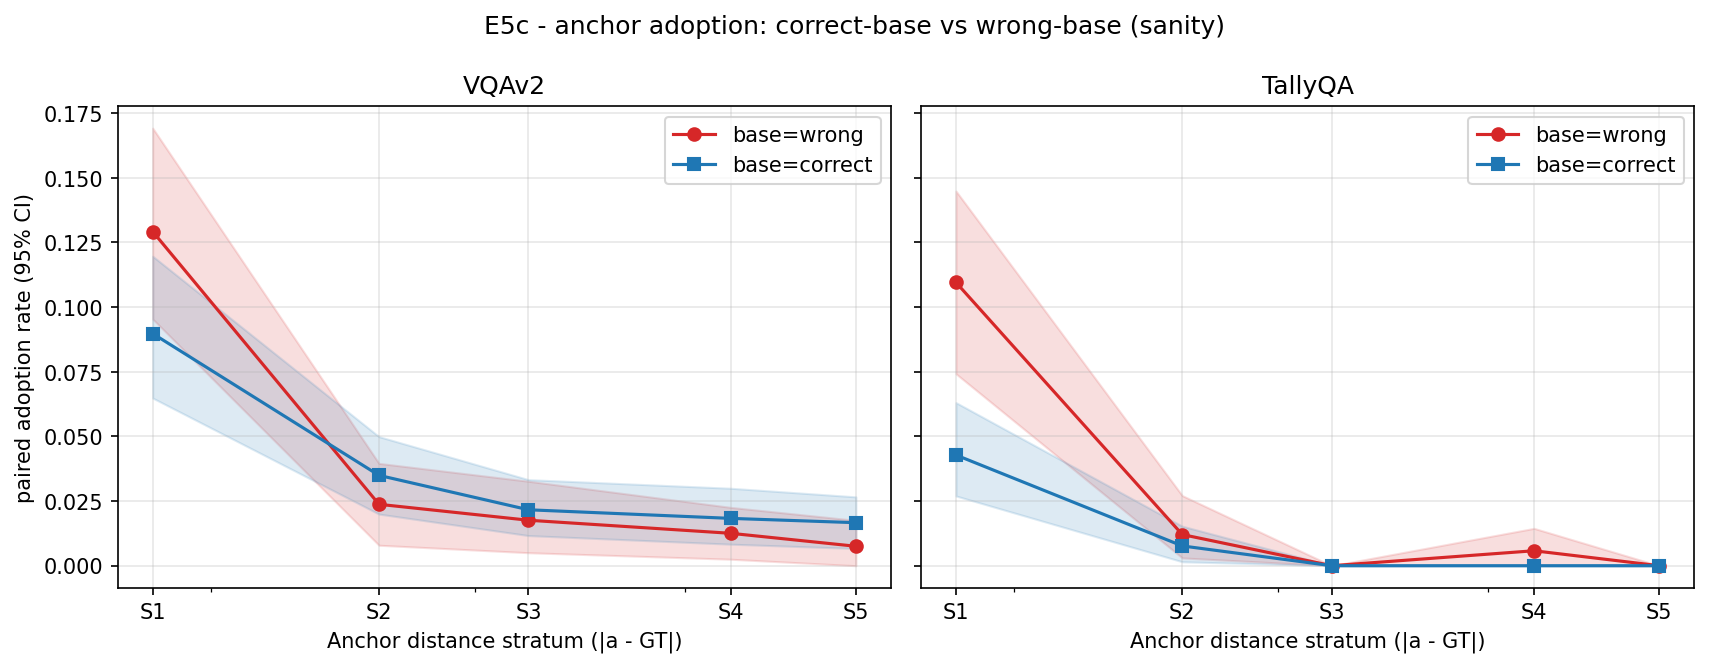

In [5]:
display(Image(filename=str(ROOT / 'docs' / 'figures' / 'E5c_correct_vs_wrong.png')))

## Sanity check - wrong-base S1 anchor vs masked vs neutral

Headline numbers in one place. Expectation: anchor S1 stays near E5b's ~0.13 (VQAv2)
/ ~0.092 (TallyQA); masked S1 falls substantially; neutral is 0 by construction.

In [6]:
for ds in ['VQAv2', 'TallyQA']:
    cell = summary[(summary['dataset']==ds) & (summary['base']=='wrong')]
    a = cell[(cell['condition_type']=='anchor') & (cell['stratum']=='S1')]['adopt_cond'].iloc[0]
    m = cell[(cell['condition_type']=='masked') & (cell['stratum']=='S1')]['adopt_cond'].iloc[0]
    n = cell[(cell['condition_type']=='neutral')]['adopt_cond'].iloc[0]
    print(f'{ds:<8s} wrong-base S1: anchor={a:.4f}, masked={m:.4f}, neutral(all)={n:.4f}, anchor/masked={a/m if m>0 else float("inf"):.2f}x')
print()
print(out['headline'])

VQAv2    wrong-base S1: anchor=0.1292, masked=0.0681, neutral(all)=0.0000, anchor/masked=1.90x
TallyQA  wrong-base S1: anchor=0.1095, masked=0.0842, neutral(all)=0.0000, anchor/masked=1.30x

=== E5c headline (wrong-base, paired conditional) ===
Dataset   Stratum       anchor    masked   neutral
VQAv2     S1            0.1292    0.0681       n/a
VQAv2     S2            0.0237    0.0079       n/a
VQAv2     S3            0.0176    0.0050       n/a
VQAv2     S4            0.0125    0.0000       n/a
VQAv2     S5            0.0075    0.0000       n/a
TallyQA   S1            0.1095    0.0842       n/a
TallyQA   S2            0.0120    0.0120       n/a
TallyQA   S3            0.0000    0.0000       n/a
TallyQA   S4            0.0058    0.0000       n/a
TallyQA   S5            0.0000    0.0000       n/a

neutral (across all)               VQAv2   TallyQA
wrong-base                        0.0000    0.0000
